# Fertilizer Recommendation Analysis

This notebook analyzes the fertilizer recommendation dataset, evaluates the performance of a Random Forest model, and visualizes key insights. We'll cover:
- Loading and preparing the data
- Training the model and evaluating its accuracy
- Visualizing feature importance, confusion matrix, and fertilizer distribution

## Step 1: Import Libraries and Load Data

In this cell, we import the necessary Python libraries for data processing, model training, and visualization. We also load the fertilizer recommendation dataset from the CSV file.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data/fertilizer_recommendation_dataset.csv')

# Display the first few rows to understand the data
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3100, 12)


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


## Step 2: Prepare Data and Train the Model

Here, we prepare the features and target variable for training. Categorical variables (Soil and Crop) are encoded using LabelEncoder. We then split the data into training and testing sets and train a Random Forest Classifier.

In [2]:
# Prepare features and target
X = df[['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil', 'Crop']].copy()  # Create a copy to avoid warnings
y = df['Fertilizer']

# Encode categorical variables
le_soil = LabelEncoder()
le_crop = LabelEncoder()
X.loc[:, 'Soil'] = le_soil.fit_transform(X['Soil'])  # Use .loc to avoid warnings
X.loc[:, 'Crop'] = le_crop.fit_transform(X['Crop'])  # Use .loc to avoid warnings

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate and display the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2%}')

# Display the classification report for detailed metrics
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Training set size: 2480 samples
Testing set size: 620 samples
Model Accuracy: 98.87%

Classification Report:
                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       1.00      1.00      1.00        32
                   Compost       0.99      0.99      0.99        84
                       DAP       0.99      1.00      0.99       206
General Purpose Fertilizer       1.00      1.00      1.00         7
                    Gypsum       1.00      0.67      0.80         6
                      Lime       0.97      0.97      0.97        39
         Muriate of Potash       1.00      1.00      1.00        66
        Organic Fertilizer       1.00      0.94      0.97        18
                      Urea       1.00      0.97      0.99        34
Water Retaining Fertilizer       0.98      0.99      0.99       128

                  accuracy                           0.99       620
                 macro avg       0.99      0.95      0.97       620
     

## Step 3: Visualize Feature Importance

This cell creates a bar plot to show the importance of each feature in predicting the fertilizer type. Feature importance helps us understand which factors (e.g., Nitrogen, pH) most influence the model's predictions.

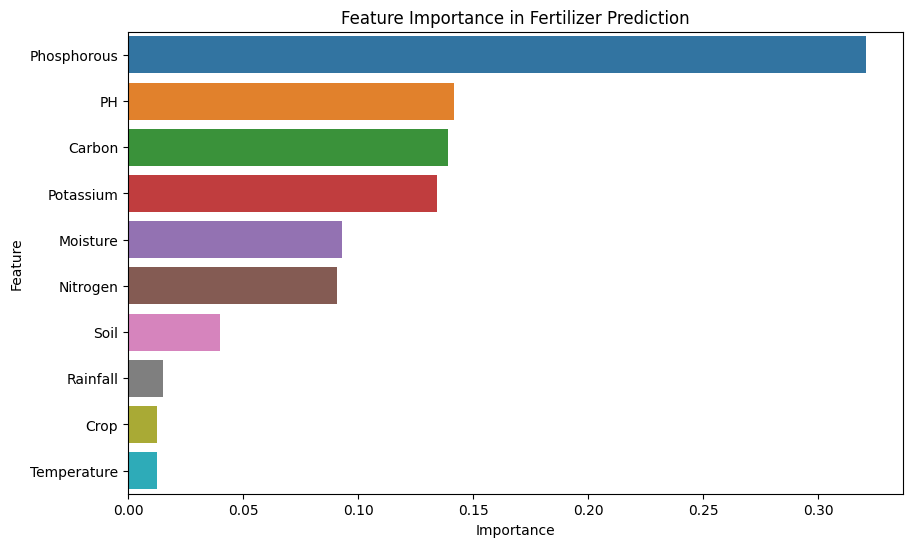

In [3]:
# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance in Fertilizer Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.savefig('feature_importance.png')
plt.show()

## Step 4: Visualize Confusion Matrix

This cell generates a heatmap of the confusion matrix, which shows how well the model predicts each fertilizer type. The diagonal values represent correct predictions, while off-diagonal values indicate misclassifications.

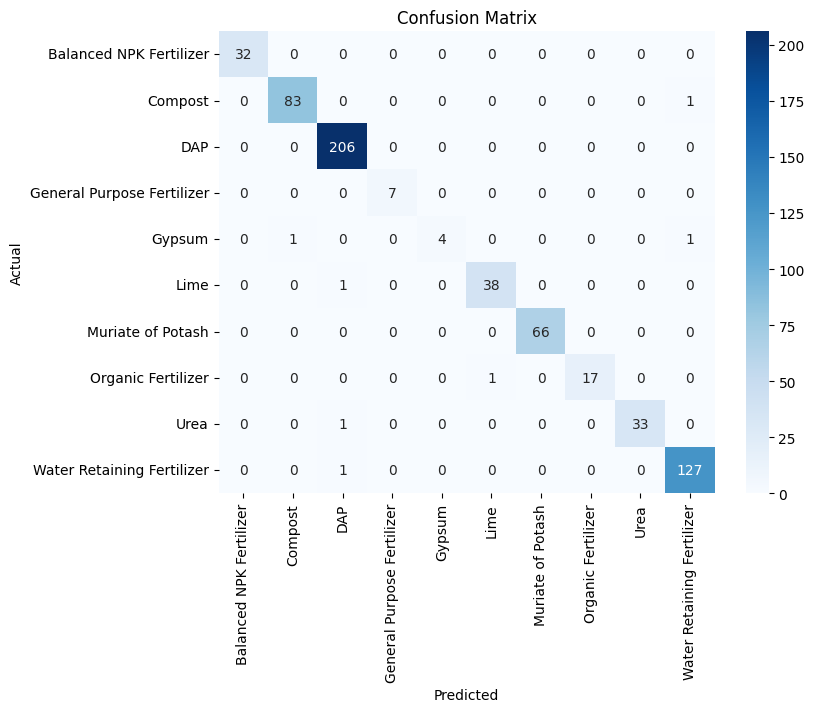

In [4]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

## Step 5: Visualize Fertilizer Recommendation Distribution

In this cell, we create a bar plot to show the distribution of fertilizer recommendations in the dataset. This helps us understand how frequently each fertilizer type is recommended.

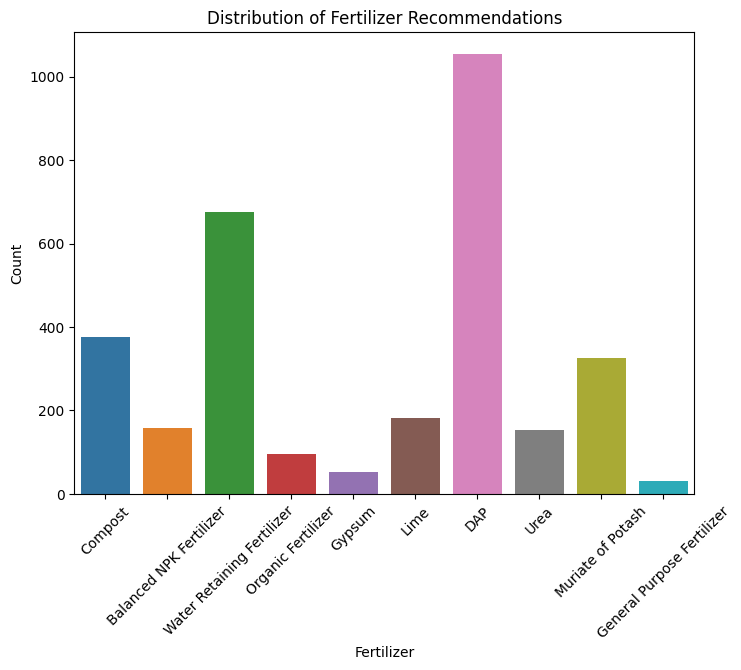

In [5]:
# Plot the distribution of fertilizer recommendations
plt.figure(figsize=(8, 6))
sns.countplot(x='Fertilizer', data=df)
plt.title('Distribution of Fertilizer Recommendations')
plt.xlabel('Fertilizer')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('fertilizer_distribution.png')
plt.show()

## Step 6: Summary

1. **Feature Importance Plot**: Shows which features most influence fertilizer predictions.
2. **Confusion Matrix**: Displays prediction accuracy across different fertilizer types.
3. **Fertilizer Distribution**: Shows the frequency of each fertilizer recommendation in the dataset.

The model's performance metrics (accuracy, precision, recall) are now based on a proper train-test split, which provides a more realistic evaluation of the model's performance.